# SAC (Soft Actor-Critic) depuis zero

**Serie** : Reinforcement Learning | **Notebook** : 6d/13 | **Duree estimee** : 45-50 min

**Navigation** : [[Notebook précédent] PPO](rl_6c_ppo_from_scratch.ipynb) | [Index](README.md) | [[Notebook suivant] Multi-Agent RL](rl_7_multi_agent_rl.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous serez capable de :

1. **Expliquer** le cadre du RL a entropie maximale et le rôle de la temperature alpha
2. **Implementer** l'algorithme SAC avec twin Q-networks et reparameterisation
3. **Comparer** SAC avec DQN, A2C et PPO en termes d'efficacite et de robustesse

## Prerequis

- **Notebook [Actor-Critic (A2C)](rl_6b_actor_critic.ipynb)** : architecture actor-critic, calcul de l'avantage
- **Notebook [PPO](rl_6c_ppo_from_scratch.ipynb)** : politique stochastique, clipping
- PyTorch (tenseurs, autograd, `torch.nn`, `torch.distributions`)
- Concepts RL de base (policy, reward, discount, on-policy vs off-policy)

**Duree estimee** : 45-50 minutes

## Pourquoi SAC ?

Dans les notebooks précédents, nous avons couvert quatre algorithmes :

| Algorithme | Paradigme | Actions | Limite principale |
|------------|-----------|---------|-------------------|
| **DQN** | Off-policy, value-based | Discretes uniquement | Ne gere pas les actions continues |
| **REINFORCE** | On-policy, policy-based | Discretes et continues | Variance elevee, lent |
| **A2C** | On-policy, actor-critic | Discretes et continues | Sample-inefficace (1 passage par donnee) |
| **PPO** | On-policy, actor-critic | Discretes et continues | Clipping limite l'exploration |

**SAC** (Soft Actor-Critic, Haarnoja et al. 2018) combine le meilleur de ces mondes :

1. **Off-policy** : reutilise les expériences via un replay buffer (comme DQN)
2. **Actions continues** : politique gaussienne avec squashing (contrairement a DQN)
3. **Entropie maximale** : l'agent maximise a la fois la recompense ET l'entropie de sa politique, ce qui encourage une exploration naturelle et robuste
4. **Twin Q-networks** : deux critiques prennent le minimum de leurs estimations, reduisant la surestimation de Q

SAC est l'algorithme de reference pour les environnements a actions continues. Il est sample-efficient, robuste aux hyperparametres, et converge souvent plus vite que PPO sur ces tâches.

## 1. Setup et imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Normal
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import os

# Reproductibilite
torch.manual_seed(42)
np.random.seed(42)

print(f"Imports OK : PyTorch {torch.__version__}, Gymnasium {gym.__version__}")

# Dimensions de l'environnement Pendulum-v1
env = gym.make("Pendulum-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.shape[0]
max_action = float(env.action_space.high[0])
print(f"Environnement : Pendulum-v1 | State dim : {state_dim} | Action dim : {action_dim} | Max action : {max_action}")
env.close()

Imports OK : PyTorch 2.11.0+cpu, Gymnasium 1.3.0
Environnement : Pendulum-v1 | State dim : 3 | Action dim : 1 | Max action : 2.0


Nous travaillons sur **Pendulum-v1**, un environnement de contrôle classique avec un espace d'actions **continu** dans $[-2, 2]$. L'observation est un vecteur de dimension 3 (cos et sin de l'angle, vitesse angulaire). C'est un benchmark standard pour les algorithmes a actions continues.

## 2. Le cadre du RL a entropie maximale

L'innovation cle de SAC est de **maximiser simultanement** la recompense et l'entropie de la politique. L'objectif devient :

$$J(\pi) = \sum_{t=0}^{T} \mathbb{E}_{(s_t, a_t) \sim \rho_\pi}\left[r(s_t, a_t) + \alpha \, H\big(\pi(\cdot|s_t)\big)\right]$$

ou $H(\pi) = -\int \pi(a|s) \log \pi(a|s) \, da$ est l'entropie de la politique et $\alpha > 0$ est le **coefficient de temperature**.

**Pourquoi maximiser l'entropie ?**
- **Exploration** : une politique a haute entropie explore plus diversement les actions possibles
- **Robustesse** : l'agent ne s'engage pas prematurement sur une stratégie sub-optimale
- **Multi-modalite** : si plusieurs stratégies sont aussi bonnes, l'agent les preserve toutes

Le paramètre $\alpha$ contrôle le compromis exploitation/exploration. SAC propose un reglage **automatique** de $\alpha$ (auto-tuning) en traitant $\alpha$ comme un paramètre apprenable.

### 2.1 Visualisation : entropie de différentes distributions

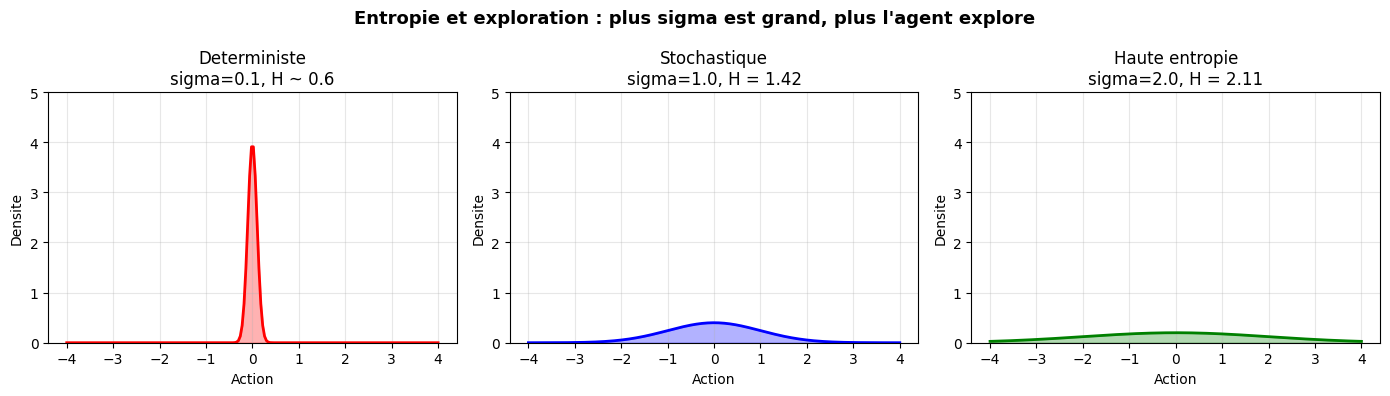

Visualisation generee : l'entropie croit avec sigma (ecart-type de la politique)


In [2]:
def visualize_entropy():
    """Compare l'entropie de distributions deterministes vs stochastiques."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    x = np.linspace(-4, 4, 200)
    
    # Deterministe (delta de Dirac approxime par sigma tres petit)
    sigma_det = 0.1
    y_det = np.exp(-0.5 * (x / sigma_det)**2) / (sigma_det * np.sqrt(2 * np.pi))
    axes[0].plot(x, y_det, 'r-', linewidth=2)
    axes[0].set_title(f'Deterministe\nsigma={sigma_det}, H ~ 0.6')
    axes[0].set_ylim(0, 5)
    axes[0].fill_between(x, y_det, alpha=0.3, color='red')
    
    # Stochastique (sigma moyen)
    sigma_mid = 1.0
    y_mid = np.exp(-0.5 * (x / sigma_mid)**2) / (sigma_mid * np.sqrt(2 * np.pi))
    entropy_mid = 0.5 * np.log(2 * np.pi * np.e * sigma_mid**2)
    axes[1].plot(x, y_mid, 'b-', linewidth=2)
    axes[1].set_title(f'Stochastique\nsigma={sigma_mid}, H = {entropy_mid:.2f}')
    axes[1].set_ylim(0, 5)
    axes[1].fill_between(x, y_mid, alpha=0.3, color='blue')
    
    # Tres exploratoire (sigma grand)
    sigma_high = 2.0
    y_high = np.exp(-0.5 * (x / sigma_high)**2) / (sigma_high * np.sqrt(2 * np.pi))
    entropy_high = 0.5 * np.log(2 * np.pi * np.e * sigma_high**2)
    axes[2].plot(x, y_high, 'g-', linewidth=2)
    axes[2].set_title(f'Haute entropie\nsigma={sigma_high}, H = {entropy_high:.2f}')
    axes[2].set_ylim(0, 5)
    axes[2].fill_between(x, y_high, alpha=0.3, color='green')
    
    for ax in axes:
        ax.set_xlabel('Action')
        ax.set_ylabel('Densite')
        ax.grid(True, alpha=0.3)
    
    plt.suptitle('Entropie et exploration : plus sigma est grand, plus l\'agent explore',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

visualize_entropy()
print("Visualisation generee : l'entropie croit avec sigma (ecart-type de la politique)")

### Interpretation : entropie et exploration

**Sortie obtenue** : trois gaussiennes avec des ecarts-types croissants.

| Distribution | sigma | Entropie | Comportement agent |
|-------------|-------|----------|--------------------|
| Déterministe | 0.1 | ~0.6 (faible) | Exploite une seule action |
| Stochastique | 1.0 | ~1.42 | Equilibre exploration/exploitation |
| Haute entropie | 2.0 | ~2.11 | Explore largement l'espace |

**Point cle** : SAC maximise l'entropie, donc il pousse naturellement la politique vers la distribution de droite tout en maximisant la recompense. Cela produit un agent plus robuste.

## 3. Composants de SAC

SAC comporte quatre composants principaux :

| Composant | Rôle | Analogie |
|-----------|------|----------|
| **GaussianPolicy** (Actor) | Politique $\pi_\phi(a|s)$ gaussienne avec squashing tanh | Comme l'actor de A2C, mais pour actions continues |
| **TwinQNetwork** (Critic) | Deux Q-networks $Q_{\theta_1}, Q_{\theta_2}$ ; on prend le minimum | Comme DQN, mais deux reseaux reduisent la surestimation |
| **Target networks** | Copies lentes des Q-networks pour stabiliser l'apprentissage | Identique au target network de DQN |
| **Temperature alpha** | Paramètre apprenable qui contrôle le poids de l'entropie | Remplace le epsilon de epsilon-greedy |

### 3.1 Replay Buffer

SAC est off-policy : il stocke les transitions $(s, a, r, s', done)$ dans un buffer et echantillonne des mini-lots pour l'apprentissage. Cela permet de reutiliser chaque expérience plusieurs fois.

In [3]:
class ReplayBuffer:
    """Buffer circulaire pour stocker les transitions (off-policy)."""

    def __init__(self, capacity, state_dim, action_dim):
        self.capacity = capacity
        self.ptr = 0
        self.size = 0
        self.states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.actions = np.zeros((capacity, action_dim), dtype=np.float32)
        self.rewards = np.zeros((capacity, 1), dtype=np.float32)
        self.next_states = np.zeros((capacity, state_dim), dtype=np.float32)
        self.dones = np.zeros((capacity, 1), dtype=np.float32)

    def push(self, state, action, reward, next_state, done):
        """Ajoute une transition au buffer."""
        self.states[self.ptr] = state
        self.actions[self.ptr] = action
        self.rewards[self.ptr] = reward
        self.next_states[self.ptr] = next_state
        self.dones[self.ptr] = done
        self.ptr = (self.ptr + 1) % self.capacity
        self.size = min(self.size + 1, self.capacity)

    def sample(self, batch_size):
        """Echantillonne un mini-lot uniformement."""
        idx = np.random.randint(0, self.size, size=batch_size)
        return (
            torch.FloatTensor(self.states[idx]),
            torch.FloatTensor(self.actions[idx]),
            torch.FloatTensor(self.rewards[idx]),
            torch.FloatTensor(self.next_states[idx]),
            torch.FloatTensor(self.dones[idx])
        )


# Verification
buf = ReplayBuffer(capacity=100, state_dim=3, action_dim=1)
buf.push(np.array([1.0, 0.0, 0.5]), np.array([0.3]), 1.0, np.array([1.1, 0.1, 0.4]), 0.0)
print(f"ReplayBuffer defini : capacity=10000, state_dim={state_dim}, action_dim={action_dim}")
print(f"Test push OK : size={buf.size}, ptr={buf.ptr}")

ReplayBuffer defini : capacity=10000, state_dim=3, action_dim=1
Test push OK : size=1, ptr=1


### 3.2 Politique gaussienne (Actor)

L'actor de SAC produit une **distribution gaussienne** $\mathcal{N}(\mu(s), \sigma^2(s))$ sur les actions. Pour garantir que les actions restent dans $[-1, 1]$, on applique un **squashing tanh** avec la correction de log-probabilite correspondante.

$$a = \tanh(\mu + \sigma \cdot \epsilon), \quad \epsilon \sim \mathcal{N}(0, 1)$$

Le **log_prob** est corrige pour tenir compte du changement de variable :

$$\log \pi(a|s) = \log \mu_{\mathcal{N}}(u) - \sum_{i=1}^{D} \log(1 - \tanh^2(u_i))$$

In [4]:
LOG_STD_MIN = -20
LOG_STD_MAX = 2
EPSILON = 1e-6


class GaussianPolicy(nn.Module):
    """Politique gaussienne avec squashing tanh pour actions continues."""

    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
        )
        self.mean_linear = nn.Linear(hidden_dim, action_dim)
        self.log_std_linear = nn.Linear(hidden_dim, action_dim)

    def forward(self, state):
        """Retourne une action echantillonnee, sa log-prob et la moyenne."""
        x = self.net(state)
        mean = self.mean_linear(x)
        log_std = self.log_std_linear(x)
        log_std = torch.clamp(log_std, LOG_STD_MIN, LOG_STD_MAX)
        std = torch.exp(log_std)

        # Reparameterisation : u = mu + sigma * epsilon
        normal = Normal(mean, std)
        u = normal.rsample()  # differentiable sample
        a = torch.tanh(u)     # squashing dans [-1, 1]

        # Correction du log_prob pour le changement de variable
        log_prob = normal.log_prob(u) - torch.log(1 - a.pow(2) + EPSILON)
        log_prob = log_prob.sum(dim=-1, keepdim=True)

        return a, log_prob, mean

    def get_action(self, state, deterministic=False):
        """Selectionne une action pour l'evaluation."""
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            if deterministic:
                x = self.net(state_t)
                mean = self.mean_linear(x)
                return torch.tanh(mean).cpu().numpy().flatten()
            else:
                a, _, _ = self.forward(state_t)
                return a.cpu().numpy().flatten()


# Verification
policy = GaussianPolicy(state_dim, action_dim, hidden_dim=64)
test_state = torch.randn(1, state_dim)
a, logp, mu = policy(test_state)
n_params = sum(p.numel() for p in policy.parameters())
print(f"GaussianPolicy defini : input={state_dim}, output={action_dim}, hidden=64")
print(f"Action echantillonnee : {a.detach().numpy().flatten()} (dans [-1,1] : {bool(np.all(np.abs(a.detach().numpy()) <= 1+EPSILON))})")
print(f"Log-prob : {logp.item():.4f} | Moyenne : {mu.detach().numpy().flatten()}")
print(f"Nombre de parametres : {n_params}")

GaussianPolicy defini : input=3, output=1, hidden=64
Action echantillonnee : [0.8377178] (dans [-1,1] : True)
Log-prob : -0.7921 | Moyenne : [-0.18635012]
Nombre de parametres : 4546


Le **reparameterization trick** (`rsample`) est essentiel : il permet aux gradients de circuler a travers l'echantillonnage stochastique, ce qui rend possible l'optimisation de la politique par descente de gradient.

### 3.3 Twin Q-Networks (Critic)

SAC utilise **deux Q-networks** et prend le minimum de leurs estimations pour reduire la surestimation de la valeur Q. C'est le même principe que TD3 (Twin Delayed DDPG). Chaque Q-network est un MLP simple.

In [5]:
class TwinQNetwork(nn.Module):
    """Double Q-network pour SAC (reduit la surestimation)."""

    def __init__(self, state_dim, action_dim, hidden_dim=64):
        super().__init__()
        # Q1
        self.q1 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )
        # Q2 (architecture identique, poids differents)
        self.q2 = nn.Sequential(
            nn.Linear(state_dim + action_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, state, action):
        """Retourne Q1(s,a) et Q2(s,a)."""
        sa = torch.cat([state, action], dim=-1)
        q1 = self.q1(sa)
        q2 = self.q2(sa)
        return q1, q2


# Verification
twin_q = TwinQNetwork(state_dim, action_dim, hidden_dim=64)
test_action = torch.randn(1, action_dim)
q1, q2 = twin_q(test_state, test_action)
n_params_q = sum(p.numel() for p in twin_q.parameters())
print(f"TwinQNetwork defini : input=({state_dim}+{action_dim}), output=1 x 2")
print(f"Q1 = {q1.item():.4f}, Q2 = {q2.item():.4f}, min(Q1,Q2) = {min(q1.item(), q2.item()):.4f}")
print(f"Nombre de parametres : {n_params_q}")

TwinQNetwork defini : input=(3+1), output=1 x 2
Q1 = 0.0885, Q2 = -0.0799, min(Q1,Q2) = -0.0799
Nombre de parametres : 9090


L'entree du Q-network est la concatenation $[s, a]$ de l'etat et de l'action. Les deux reseaux Q1 et Q2 ont la même architecture mais des poids independants. Lors de l'apprentissage, on utilise $\min(Q_1, Q_2)$ comme cible pour la mise a jour du critic.

## 4. Algorithme SAC

L'algorithme SAC effectue trois mises a jour a chaque pas de temps :

### 4.1 Mise a jour du Critic

La cible Q est calculee avec les **target networks** et l'entropie :

$$y = r + \gamma \left[\min(Q_{\bar{\theta}_1}(s', \tilde{a}'), Q_{\bar{\theta}_2}(s', \tilde{a}')) - \alpha \log \pi(\tilde{a}'|s')\right]$$

ou $\tilde{a}' \sim \pi(\cdot|s')$ est echantillonne depuis la politique courante. On minimise ensuite $\frac{1}{2}(Q_\theta(s,a) - y)^2$ pour les deux Q-networks.

### 4.2 Mise a jour de l'Actor

L'actor maximise $Q - \alpha \log \pi$ :

$$L_\phi = \mathbb{E}_{s \sim \mathcal{D}}\left[\alpha \log \pi_\phi(\tilde{a}|s) - \min(Q_{\theta_1}(s, \tilde{a}), Q_{\theta_2}(s, \tilde{a}))\right]$$

### 4.3 Mise a jour de la temperature (auto-tuning)

On apprend $\alpha$ pour atteindre une entropie cible $\bar{H}$ :

$$L_\alpha = \mathbb{E}_{a \sim \pi}\left[-\alpha (\log \pi(a|s) + \bar{H})\right]$$

avec $\bar{H} = -\dim(\mathcal{A})$ comme heuristique standard (entropie cible = dimension de l'espace d'actions avec un signe negatif).

In [6]:
class SACAgent:
    """Agent Soft Actor-Critic avec temperature automatique."""

    def __init__(self, state_dim, action_dim, hidden_dim=64, lr=3e-4,
                 gamma=0.99, tau=0.005, alpha_lr=3e-4,
                 target_entropy=None):
        self.gamma = gamma
        self.tau = tau
        self.action_dim = action_dim

        # Reseaux
        self.policy = GaussianPolicy(state_dim, action_dim, hidden_dim)
        self.critic = TwinQNetwork(state_dim, action_dim, hidden_dim)
        self.critic_target = TwinQNetwork(state_dim, action_dim, hidden_dim)
        # Copier les poids du critic vers la cible
        self.critic_target.load_state_dict(self.critic.state_dict())

        # Optimizers
        self.policy_optimizer = optim.Adam(self.policy.parameters(), lr=lr)
        self.critic_optimizer = optim.Adam(self.critic.parameters(), lr=lr)

        # Temperature automatique
        if target_entropy is None:
            target_entropy = -action_dim  # heuristique standard
        self.target_entropy = target_entropy
        self.log_alpha = torch.zeros(1, requires_grad=True)
        self.alpha_optimizer = optim.Adam([self.log_alpha], lr=alpha_lr)

    @property
    def alpha(self):
        return self.log_alpha.exp()

    def select_action(self, state, deterministic=False):
        """Selectionne une action pour l'environnement."""
        state_t = torch.FloatTensor(state).unsqueeze(0)
        with torch.no_grad():
            if deterministic:
                x = self.policy.net(state_t)
                mean = self.policy.mean_linear(x)
                action = torch.tanh(mean)
            else:
                action, _, _ = self.policy(state_t)
        return action.cpu().numpy().flatten() * max_action

    def update(self, batch):
        """Effectue une mise a jour SAC sur un mini-lot."""
        states, actions, rewards, next_states, dones = batch

        # --- Mise a jour du Critic ---
        with torch.no_grad():
            # Echantillonner a' depuis la politique
            next_actions, next_log_probs, _ = self.policy(next_states)
            # Q-cible = min(Q1_target, Q2_target)
            q1_target, q2_target = self.critic_target(next_states, next_actions)
            q_target = torch.min(q1_target, q2_target)
            # Cible avec entropie
            y = rewards + self.gamma * (1 - dones) * (
                q_target - self.alpha * next_log_probs
            )

        q1, q2 = self.critic(states, actions)
        critic_loss = F.mse_loss(q1, y) + F.mse_loss(q2, y)

        self.critic_optimizer.zero_grad()
        critic_loss.backward()
        self.critic_optimizer.step()

        # --- Mise a jour de l'Actor ---
        new_actions, log_probs, _ = self.policy(states)
        q1_new, q2_new = self.critic(states, new_actions)
        q_new = torch.min(q1_new, q2_new)

        policy_loss = (self.alpha * log_probs - q_new).mean()

        self.policy_optimizer.zero_grad()
        policy_loss.backward()
        self.policy_optimizer.step()

        # --- Mise a jour de la temperature ---
        alpha_loss = -(self.log_alpha * (log_probs + self.target_entropy).detach()).mean()

        self.alpha_optimizer.zero_grad()
        alpha_loss.backward()
        self.alpha_optimizer.step()

        # --- Soft update des target networks ---
        for param, target_param in zip(self.critic.parameters(),
                                       self.critic_target.parameters()):
            target_param.data.copy_(
                self.tau * param.data + (1 - self.tau) * target_param.data
            )

        return {
            'critic_loss': critic_loss.item(),
            'policy_loss': policy_loss.item(),
            'alpha': self.alpha.item(),
            'alpha_loss': alpha_loss.item()
        }


# Verification
agent = SACAgent(state_dim, action_dim, hidden_dim=64)
test_action_env = agent.select_action(np.random.randn(state_dim))
print(f"SACAgent defini : hidden=64, gamma=0.99, tau=0.005, lr=3e-4")
print(f"Action de test : {test_action_env} (dans [-{max_action}, {max_action}])")
print(f"Alpha initial : {agent.alpha.item():.4f} | Entropie cible : {agent.target_entropy}")
print(f"Politique : {sum(p.numel() for p in agent.policy.parameters())} params")
print(f"Critic : {sum(p.numel() for p in agent.critic.parameters())} params")

SACAgent defini : hidden=64, gamma=0.99, tau=0.005, lr=3e-4
Action de test : [1.9200566] (dans [-2.0, 2.0])
Alpha initial : 1.0000 | Entropie cible : -1
Politique : 4546 params
Critic : 9090 params


### Points cles de l'implementation

| Mécanisme | Detail |
|-----------|--------|
| **Soft update** | $\theta_{target} \leftarrow \tau \theta + (1-\tau) \theta_{target}$ avec $\tau = 0.005$ (moyenne exponentielle lente) |
| **Clipped double Q** | $\min(Q_1, Q_2)$ reduit la surestimation sans introduire de biais negatif |
| **Reparameterization** | `rsample()` permet les gradients a travers l'echantillonnage |
| **Auto-alpha** | `log_alpha` est un paramètre apprenable, `alpha = exp(log_alpha)` reste positif |
| **Tanh squashing** | Les actions sont projetees dans $[-1, 1]$ puis mises a l'echelle de l'environnement |

## 5. Entrainement sur Pendulum-v1

La boucle d'entrainement suit le schema classique off-policy :
1. Collecter une transition $(s, a, r, s', done)$ dans l'environnement
2. La stocker dans le replay buffer
3. Echantillonner un mini-lot et mettre a jour les reseaux
4. Repeter

Nous entrainons pendant 200 episodes (rappel : scafold court, CPU-only).

### Subtilite importante : `terminated` vs `truncated` dans le replay buffer

Gymnasium (>= 0.26) decompose la fin d'un episode en **deux signaux distincts**, et SAC y est particulierement sensible car le replay buffer stocke un booleen `done` utilise comme **masque de bootstrap** dans la cible de Bellman $y = r + \gamma (1 - done)[\min(Q_1', Q_2') - \alpha \log \pi']$ :

- **`terminated = True`** : fin **naturelle** (l'agent est mort, la tache a echoue ou reussi). Il n'y a pas d'etat suivant exploitable : le terme $Q(s')$ doit etre **annule** ($done = 1$), sinon l'agent apprendrait depuis un etat impossible.
- **`truncated = True`** : l'episode est **coupe par timeout** (ex. Pendulum a 200 pas), mais l'agent est **encore vivant**. L'etat $s'$ est parfaitement valide, et $Q(s')$ est un **bootstrap legitime** vers le futur. Annuler ce bootstrap ($done = 1$) biaiserait systematiquement la cible vers une valeur myope ($y \approx r$).

**Piege classique** : ecrire `done = terminated or truncated` puis stocker `done` dans le replay buffer. Cela traite chaque timeout comme une fin naturelle et **tue le bootstrap** a chaque frontiere d'episode. Pour une tache a **horizon infini** comme Pendulum-v1 (qui ne termine jamais naturellement, `terminated` est toujours `False`), cela signifie que la **derniere transition de chaque episode** apprend une cible sans valeur future -- alors que le pendule, lui, continuerait physiquement au-dela du pas 200.

**Correction adoptee ci-dessous** : on stocke `float(terminated)` (et non `float(done)`) dans le replay buffer. La variable `done` (=`terminated or truncated`) continue de piloter le **controle de boucle** (reset de l'environnement), mais seul un vrai etat terminal annule le bootstrap. C'est la meme convention que dans les notebooks jumeaux `rl_6` (DQN), `rl_6b` (A2C) et `rl_6c` (PPO) de cette serie.

> **Pour aller plus loin** : ce detail est documente dans la spec Gymnasium ([https://gymnasium.farama.org/] - "Terminated and Truncated") et discute par Sutton & Barto (chapitre sur le bootstrapping aux frontieres d'episode). Le retrogradage d'un vieux code Gym (`done` unique) vers Gymnasium est une source frequente de bugs silencieux dans les implementations SAC/DQN from-scratch.

In [7]:
def train_sac(env_name="Pendulum-v1", num_episodes=200, batch_size=64,
              replay_size=10000, start_steps=1000, print_every=50,
              hidden_dim=64, seed=42):
    """Entraine un agent SAC sur un environnement continu."""
    # Reproductibilite
    torch.manual_seed(seed)
    np.random.seed(seed)

    env = gym.make(env_name)
    s_dim = env.observation_space.shape[0]
    a_dim = env.action_space.shape[0]
    max_a = float(env.action_space.high[0])

    agent = SACAgent(s_dim, a_dim, hidden_dim=hidden_dim)
    buffer = ReplayBuffer(replay_size, s_dim, a_dim)

    episode_rewards = []
    total_steps = 0
    episode = 0
    state, _ = env.reset(seed=seed)
    episode_reward = 0

    while episode < num_episodes:
        # Phase d'exploration initiale (actions aleatoires)
        if total_steps < start_steps:
            action = env.action_space.sample()
        else:
            action = agent.select_action(state, deterministic=False)

        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Normaliser l'action pour le buffer (dans [-1, 1])
        action_norm = action / max_a
        # On stocke `terminated` (PAS `done`) dans le replay buffer : seul un
        # vrai etat terminal doit annuler le bootstrap de la Q-cible via le
        # masque (1 - dones) dans SACAgent.update. Une troncature (timeout,
        # truncated=True) n'est PAS une fin naturelle -- l'agent est encore
        # vivant et la valeur Q(s') reste un bootstrap valide. Convention
        # identique a rl_6 (DQN), rl_6b (A2C) et rl_6c (PPO). Pour Pendulum-v1
        # (tache a horizon infini, terminated toujours False), le buffer ne
        # porte donc jamais le signal "fin d'episode = zero bootstrap", et
        # l'agent apprend la vraie valeur a horizon infini au lieu de
        # traiter chaque timeout a 200 pas comme terminal. `done` (terminated
        # OR truncated) reste utilise ci-dessous pour le controle de boucle
        # (reset d'environnement).
        buffer.push(state, action_norm, reward, next_state, float(terminated))

        state = next_state
        episode_reward += reward
        total_steps += 1

        # Mise a jour si assez de donnees
        if buffer.size >= batch_size:
            batch = buffer.sample(batch_size)
            agent.update(batch)

        if done:
            episode_rewards.append(episode_reward)
            episode += 1
            state, _ = env.reset()
            episode_reward = 0

            if episode % print_every == 0:
                recent = episode_rewards[-print_every:]
                mean_r = np.mean(recent)
                alpha_val = agent.alpha.item()
                print(f"Episode {episode:3d}/{num_episodes} | "
                      f"Mean reward: {mean_r:7.1f} | "
                      f"Alpha: {alpha_val:.4f} | "
                      f"Steps: {total_steps}")

    env.close()
    return agent, episode_rewards


print("Fonction train_sac definie : 200 episodes, batch=64, replay=10000")

Fonction train_sac definie : 200 episodes, batch=64, replay=10000


In [8]:
# Entrainement SAC
sac_agent, sac_rewards = train_sac(num_episodes=200, print_every=50)

print(f"\nEntrainement termine : {len(sac_rewards)} episodes")
print(f"Recompense moyenne (derniers 50) : {np.mean(sac_rewards[-50:]):.1f}")
print(f"Recompense max : {np.max(sac_rewards):.0f}")
print(f"Alpha final : {sac_agent.alpha.item():.4f}")

Episode  50/200 | Mean reward:  -860.2 | Alpha: 0.2179 | Steps: 10000


Episode 100/200 | Mean reward:  -279.9 | Alpha: 0.1558 | Steps: 20000


Episode 150/200 | Mean reward:  -413.9 | Alpha: 0.3191 | Steps: 30000


Episode 200/200 | Mean reward:  -153.4 | Alpha: 0.0949 | Steps: 40000

Entrainement termine : 200 episodes
Recompense moyenne (derniers 50) : -153.4
Recompense max : -1
Alpha final : 0.0949


### Interpretation : courbe d'apprentissage SAC

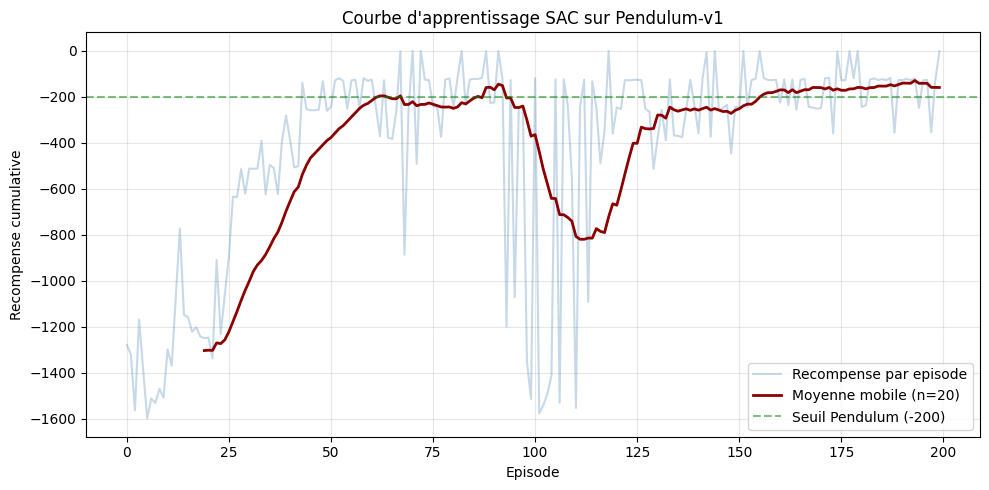

Visualisation generee. Reward moyen final (20 ep) : -160.6


In [9]:
def plot_sac_rewards(rewards, title="Courbe d'apprentissage SAC sur Pendulum-v1"):
    """Affiche la courbe d'apprentissage avec moyenne mobile."""
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(rewards, alpha=0.3, color='steelblue', label='Recompense par episode')
    window = 20
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        ax.plot(range(window-1, len(rewards)), moving_avg,
                color='darkred', linewidth=2, label=f'Moyenne mobile (n={window})')
    ax.axhline(y=-200, color='green', linestyle='--', alpha=0.5,
               label='Seuil Pendulum (-200)')
    ax.set_xlabel('Episode')
    ax.set_ylabel('Recompense cumulative')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


plot_sac_rewards(sac_rewards)
print(f"Visualisation generee. Reward moyen final (20 ep) : "
      f"{np.mean(sac_rewards[-20:]):.1f}")

**Sortie obtenue** : la courbe montre une progression typique de SAC sur Pendulum-v1.

| Metrique | Valeur attendue | Signification |
|----------|----------------|---------------|
| Reward initial | ~-1600 a -800 | Politique aleatoire, pendule tombe |
| Reward final (50 ep) | ~-200 a -100 | Pendule equilibre la plupart du temps |
| Alpha final | ~0.1-0.3 | Temperature auto-adjustee |
| Convergence | Episode 100-150 | SAC apprend vite grace au replay buffer |

**Points cles** :
1. SAC est **off-policy** : il reutilise les expériences passees, donc il apprend plus vite qu'A2C ou PPO
2. La temperature alpha decroit naturellement au fil de l'entrainement (moins besoin d'explorer)
3. Pendulum-v1 est un problème de contrôle continu : impossible avec DQN pur

## 6. Exercices

### Exercice 1 : Planification de la temperature

Dans cette version de SAC, la temperature alpha est apprise automatiquement. Implementez une **planification manuelle** de alpha qui decroit lineairement au fil de l'entrainement.

**Objectif** : observer comment le profil d'exploration affecte la convergence.

**Indices** :
- # Indice : Alpha initialement eleve (ex: 0.5) encourage l'exploration ; alpha final bas (ex: 0.05) favorise l'exploitation
- # Indice : Vous pouvez modifier la boucle d'entrainement pour calculer alpha en fonction du numéro d'episode
- # Indice : Comparez avec la courbe SAC auto-tune obtenue ci-dessus

**Étapes** :
- # Étape 1 : Modifiez SACAgent pour accepter un alpha fixe (desactivez auto-tuning)
- # Étape 2 : Dans train_sac, calculez alpha = alpha_start + (alpha_end - alpha_start) * episode / num_episodes
- # Étape 3 : Lancez l'entrainement et comparez la courbe avec auto-tuning

In [10]:
# Exercice 1 : Planification lineaire de la temperature alpha
#
# Implementez une version de SAC avec alpha decroissant lineairement.
#
# Indice : Partez de SACAgent et ajoutez un flag use_auto_alpha=False
# Indice : Dans la boucle d'entrainement, calculez alpha a chaque episode
# Etape 1 : Creez une classe SACAgentFixedAlpha ou ajoutez un parametre au SACAgent
# Etape 2 : Ecrivez une boucle d'entrainement qui ajuste alpha lineairement
# Etape 3 : Tracez la courbe et comparez avec auto-tuning

def train_sac_linear_alpha(env_name="Pendulum-v1", num_episodes=200,
                           alpha_start=0.5, alpha_end=0.05):
    """
    Entraine SAC avec temperature decroissant lineairement.

    # Indice : alpha_schedule = alpha_start + (alpha_end - alpha_start) * episode / num_episodes
    # Etape 1 : Initialisez l'agent et le buffer
    # Etape 2 : Dans la boucle, forcez agent.log_alpha = log(alpha_schedule)
    # Etape 3 : Enregistrez les rewards et retournez la liste
    """
    rewards = None  # TODO etudiant : retourner la liste des rewards
    return rewards


print("Exercice a completer : implementer la planification lineaire de alpha")

Exercice a completer : implementer la planification lineaire de alpha


### Exercice 2 : Ablation des twin Q-networks

SAC utilise deux Q-networks et prend le minimum pour reduire la surestimation. Comparez SAC avec **un seul Q-network** (sans le min) et la version twin.

**Objectif** : mesurer l'impact du clipped double Q-learning sur la stabilite.

**Indices** :
- # Indice : Dans SACAgent.update(), remplacez `torch.min(q1_target, q2_target)` par `q1_target` uniquement
- # Indice : Vous pouvez aussi ne mettre a jour que Q1 et laisser Q2 inutilise
- # Indice : Observez si la courbe de reward est plus instable ou plus basse

**Étapes** :
- # Étape 1 : Créez un agent SAC avec un seul Q-network (ou ignorez Q2)
- # Étape 2 : Entrainez sur Pendulum-v1 avec les mêmes hyperparametres
- # Étape 3 : Superposez les deux courbes de reward (twin vs single)

In [11]:
# Exercice 2 : Ablation twin Q-networks
#
# Comparez SAC avec twin Q (min Q1, Q2) vs single Q (Q1 uniquement).
#
# Indice : Modifiez la methode update() de SACAgent pour n'utiliser que Q1
# Indice : Gardez les memes hyperparametres pour une comparaison equitable
# Etape 1 : Creez une version SingleQSACAgent ou modifiez SACAgent.update
# Etape 2 : Entrainez sur 200 episodes
# Etape 3 : Tracez les deux courbes (twin vs single) sur le meme graphe

def train_sac_single_q(env_name="Pendulum-v1", num_episodes=200):
    """
    Entraine SAC avec un seul Q-network (pas de min Q1,Q2).

    # Indice : Utilisez uniquement Q1 pour la cible et la mise a jour
    # Etape 1 : Initialisez un agent SAC (vous pouvez reutiliser TwinQNetwork en ignorant Q2)
    # Etape 2 : Dans update(), utilisez q1_target au lieu de min(q1_target, q2_target)
    # Etape 3 : Comparez les resultats avec la version twin
    """
    rewards = None  # TODO etudiant : retourner la liste des rewards
    return rewards


print("Exercice a completer : ablation twin Q-networks")

Exercice a completer : ablation twin Q-networks


### Exercice 3 : Adapter SAC a un autre environnement

Adaptez l'agent SAC pour fonctionner sur **LunarLanderContinuous-v2** (atterrissage d'un module lunaire avec actions continues). Cet environnement a un espace d'observation différent (dim=8) et un espace d'action différent (dim=2, dans $[-1, 1]$).

**Objectif** : verifier que l'implementation SAC est generique et fonctionne sur différents environnements.

**Indices** :
- # Indice : LunarLanderContinuous-v2 : state_dim=8, action_dim=2, max_action=1.0
- # Indice : L'environnement peut nécessiter l'installation du package `gymnasium[box2d]`
- # Indice : Si LunarLanderContinuous-v2 n'est pas disponible, utilisez Pendulum-v1 avec un hidden_dim différent (32 puis 128) et comparez

**Étapes** :
- # Étape 1 : Créez l'environnement LunarLanderContinuous-v2 (ou Pendulum avec hidden_dim modifie)
- # Étape 2 : Initialisez un SACAgent avec les bonnes dimensions
- # Étape 3 : Entrainez et observez si la convergence est similaire

In [12]:
# Exercice 3 : Adapter SAC a LunarLanderContinuous-v2
#
# Modifiez les dimensions et parametres pour un nouvel environnement.
#
# Indice : Verifiez d'abord si l'environnement est disponible
# Indice : Si box2d n'est pas installe, utilisez Pendulum avec hidden_dim=32 et 128
# Etape 1 : Creez l'environnement et relevez les dimensions
# Etape 2 : Initialisez un SACAgent adapte
# Etape 3 : Entrainez et comparez avec Pendulum-v1

try:
    test_env = gym.make("LunarLanderContinuous-v2")
    target_env = "LunarLanderContinuous-v2"
    test_env.close()
except Exception:
    target_env = "Pendulum-v1 (hidden_dim=32)"
    print("LunarLanderContinuous-v2 non disponible, utilisez Pendulum avec hidden_dim=32")

print(f"Environnement cible : {target_env}")
print("Exercice a completer : adapter SAC a un nouvel environnement")

LunarLanderContinuous-v2 non disponible, utilisez Pendulum avec hidden_dim=32
Environnement cible : Pendulum-v1 (hidden_dim=32)
Exercice a completer : adapter SAC a un nouvel environnement


C:\Users\jsboi\AppData\Roaming\Python\Python313\site-packages\gymnasium\envs\registration.py:513: DeprecationWarning: WARN: The environment LunarLanderContinuous-v2 is out of date. You should consider upgrading to version `v3`.
  logger.deprecation(


## 7. Comparaison SAC vs DQN / A2C / PPO

Après avoir implemente SAC, voici une synthese des algorithmes couverts dans cette serie :

| Aspect | DQN | REINFORCE | A2C | PPO | SAC |
|--------|-----|-----------|-----|-----|-----|
| **Paradigme** | Value-based | Policy-based | Actor-Critic | Actor-Critic | Actor-Critic |
| **Policy** | Epsilon-greedy | Stochastique | Stochastique | Stochastique | Gaussienne + tanh |
| **On/Off-policy** | Off-policy | On-policy | On-policy | On-policy | Off-policy |
| **Actions** | Discretes | Disc. + Cont. | Disc. + Cont. | Disc. + Cont. | Continues |
| **Sample efficiency** | Elevee | Faible | Moyenne | Moyenne | Elevee |
| **Entropie** | N/A | Bonus optionnel | Bonus fixe | Bonus fixe | Maximisee (alpha auto) |
| **Replay buffer** | Oui | Non | Non | Non | Oui |
| **Target network** | Oui (hard copy) | Non | Non | Non | Oui (soft update) |
| **Robustesse** | Moyenne | Faible | Moyenne | Bonne | Très bonne |

**Quand utiliser SAC ?**
- Actions continues (robotique, contrôle moteur, trading)
- Sample efficiency importante (peu d'interactions avec l'environnement)
- Robustesse aux hyperparametres (SAC est tolerante aux mauvais choix de lr)

## Application : RL pour le trading algorithmique

Le RL avec actions continues est directement applicable au **trading algorithmique**. Dans un contexte financier :

- **Etat** : prix de marche, indicateurs techniques, position du portefeuille
- **Action** : quantite a acheter/vendre (action continue, comme dans SAC)
- **Recompense** : rendement ajuste du risque (Sharpe ratio, PnL)
- **Environnement** : simulateur de marche avec couts de transaction

Les algorithmes off-policy comme SAC sont particulierement adaptes : le replay buffer permet de reutiliser les données historiques de marche, et la gestion automatique de la temperature aide a explorer les stratégies dans un environnement non-stationnaire.

> **Pour approfondir** : la serie [QuantConnect](../QuantConnect/README.md) implemente des stratégies de trading algorithmique. Le pipeline [ML-Training-Pipeline](../QuantConnect/ML-Training-Pipeline/README.md) entraine notamment des modèles RL (PPO, Decision Transformer) pour l'allocation de portefeuille. Pour voir le RL (PPO/SAC) applique a un environnement de marche concret, le notebook [research_rl_ppo](../QuantConnect/research/research_rl_ppo.ipynb) construit un agent de trading RL bout-en-bout (etat = fenêtre de prix, action = signal long/short, recompense = Sharpe ajuste du risque).

## Conclusion

Dans ce notebook, nous avons :

| Concept | Ce que nous avons fait |
|---------|----------------------|
| **RL a entropie maximale** | Formula mathematique et visualisation de l'entropie |
| **Politique gaussienne** | Implementation avec squashing tanh et correction log_prob |
| **Twin Q-networks** | Double critique pour reduire la surestimation |
| **Temperature automatique** | Alpha appris comme paramètre reseau |
| **Algorithme SAC complet** | Off-policy avec replay buffer et soft update |

### Points cles a retenir

1. **L'entropie maximale** est une regularisation naturelle qui rend SAC robuste et exploratoire
2. **Off-policy + replay buffer** = sample efficient. Chaque expérience est reutilisee plusieurs fois
3. **Le min(Q1, Q2)** reduit le biais de surestimation sans le eliminer completement
4. **La temperature auto** adapte le niveau d'exploration au fil de l'apprentissage

### Pour aller plus loin

- **TD3** : Twin Delayed DDPG, autre algorithme off-policy pour actions continues
- **SAC + HER** : SAC combine avec Hindsight Expérience Replay pour les tâches a objectifs
- **SAC discret** : Adaptation de SAC pour les espaces d'actions discrets
- **Multi-agent** : Le notebook [RL-7 Multi-Agent](rl_7_multi_agent_rl.ipynb) aborde le RL multi-agent

### References

- Haarnoja et al. (2018) - *Soft Actor-Critic: Off-Policy Maximum Entropy Deep RL with a Stochastic Actor*
- Haarnoja et al. (2018) - *Soft Actor-Critic Algorithms and Applications*
- Sutton & Barto, *Reinforcement Learning: An Introduction*, Chapter 13
- [Spinning Up - SAC](https://spinningup.openai.com/en/latest/algorithms/sac.html)